In [ ]:
# Zero-Day Attack Detection in IoMT using VAE (SimCLR not yet included)
# Dataset: CICIoMT2024 (profiling for normal, train/test for attacks)

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve, auc


In [ ]:
# ======================= SETUP =======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device used:", device)


Device used: cpu


In [ ]:
import glob

def load_and_tag(folder_path, tag):
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    dfs = []
    for file in all_files:
        try:
            df = pd.read_csv(file, low_memory=False)
            label = os.path.basename(file).replace(".pcap.csv", "").replace("_test", "").replace("_train", "").strip()
            df["Label"] = label
            df["Set"] = tag
            dfs.append(df)
        except Exception as e:
            print(f"❌ Erreur dans {file}: {e}")
    return pd.concat(dfs, ignore_index=True)


profiling_df = load_and_tag("/content/drive/MyDrive/CICIoMT2024/profiling", "profiling")
test_df      = load_and_tag("/content/drive/MyDrive/CICIoMT2024/test", "test")


In [ ]:
print("Profiling columns:", profiling_df.columns.tolist())
#print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


Profiling columns: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label', 'Set']
Test columns: ['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'Label', 'Set

In [ ]:
print("Unique labels in profiling:", profiling_df['Label'].unique() if 'Label' in profiling_df else "No label")
#print("Unique labels in train:", train_df['Label'].unique() if 'Label' in train_df else "No label")
print("Unique labels in test:", test_df['Label'].unique() if 'Label' in test_df else "No label")


Unique labels in profiling: ['Idle' 'Active' 'ActiveBroker' 'Blink_Camera_LAN_MIC'
 'Blink_Camera_LAN_WATCH' 'Blink_Camera_WAN_MIC' 'Blink_Camera_WAN_WATCH'
 'Blink_Mini_Camera_Power' 'Ecobee_Camera_LAN_MIC'
 'Ecobee_Camera_LAN_WATCH' 'Ecobee_Camera_Power' 'Ecobee_Camera_WAN_MIC'
 'Ecobee_Camera_WAN_WATCH' 'M1T_Camera_LAN_MIC' 'M1T_Camera_LAN_PHOTO'
 'M1T_Camera_LAN_PRECORDING' 'M1T_Camera_LAN_WATCH' 'M1T_Camera_Power'
 'M1T_Camera_WAN_MIC' 'M1T_Camera_WAN_PHOTO' 'M1T_Camera_WAN_RECORDING'
 'M1T_Camera_WAN_WATCH' 'Multifunctional_Pager_LAN_APP'
 'Multifunctional_Pager_LAN_PHYSICAL' 'Multifunctional_Pager_Power'
 'Multifunctional_Pager_WAN_APP' 'Multifunctional_Pager_WAN_PHYSICAL'
 'Owltron_Camera_LAN_MIC' 'Owltron_Camera_LAN_PHOTO'
 'Owltron_Camera_LAN_RECORDING' 'Owltron_Camera_LAN_WATCH'
 'Owltron_Camera_Power' 'Owltron_Camera_WAN_MIC'
 'Owltron_Camera_WAN_PHOTO' 'Owltron_Camera_WAN_RECORDING'
 'Owltron_Camera_WAN_WATCH' 'SenseUBaby_Power' 'SenseU_LAN_EMERGENCY'
 'SenseU_WAN_EMERGENC

In [ ]:
# ======================= PREPROCESSING =======================
def preprocess(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    if 'Label' in df.columns:
        df['Label'] = df['Label'].astype(str).str.strip()
        benign_keywords = ['benign', 'idle', 'active', 'power', 'wan', 'lan', 'recording', 'mic', 'watch', 'photo', 'app', 'physical', 'emergency', 'broker']
        df['Label'] = df['Label'].apply(
            lambda x: 0 if any(kw in x.lower() for kw in benign_keywords) else 1
        )

    df = df.select_dtypes(include=[np.number]).copy()
    return df

In [ ]:
profiling_data = preprocess(profiling_df)
test_data  = preprocess(test_df)

# Diagnostic: check label distribution
if 'Label' in test_data.columns:
    print("Test label distribution:", test_data['Label'].value_counts())
    unique, counts = np.unique(test_data['Label'], return_counts=True)
    print("Test set class distribution:", dict(zip(unique, counts)))

profiling_columns = profiling_data.drop(columns=['Label'], errors='ignore').columns.tolist()

def align_columns(df, reference_columns):
    df_aligned = df.copy()
    for col in reference_columns:
        if col not in df_aligned.columns:
            df_aligned[col] = 0
    df_aligned = df_aligned[reference_columns]
    return df_aligned

X_profiling_df = profiling_data[profiling_columns]
X_test_df      = align_columns(test_data, profiling_columns)

scaler = StandardScaler()
X_profiling = scaler.fit_transform(X_profiling_df)
X_test      = scaler.transform(X_test_df)

var_filter = VarianceThreshold(threshold=1e-5)
X_profiling = var_filter.fit_transform(X_profiling)
X_test      = var_filter.transform(X_test)

X_profiling = np.clip(X_profiling, -5, 5)
X_test      = np.clip(X_test, -5, 5)

Y_test = test_data['Label'].values if 'Label' in test_data.columns else np.zeros(len(test_data))


Test label distribution: Label
1    1576575
0      37607
Name: count, dtype: int64
Test set class distribution: {np.int64(0): np.int64(37607), np.int64(1): np.int64(1576575)}


In [ ]:
import numpy as np # Make sure numpy is imported

# Save the NumPy arrays
np.save("/content/drive/MyDrive/CICIoMT2024/profiling_scaled.npy", X_profiling)
np.save("/content/drive/MyDrive/CICIoMT2024/train_scaled.npy", X_train)
np.save("/content/drive/MyDrive/CICIoMT2024/test_scaled.npy", X_test)

In [ ]:

# ======================= VAE =======================
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder_bn = nn.BatchNorm1d(input_dim)
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 128)
        self.fc3 = nn.Linear(128, input_dim)

    def encode(self, x):
        x = self.encoder_bn(x)
        h1 = torch.relu(self.fc1(x))
        logvar = self.fc_logvar(h1)
        logvar = torch.clamp(logvar, min=-10, max=10)
        return self.fc_mu(h1), logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = torch.relu(self.fc2(z))
        return self.fc3(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [ ]:
# ======================= LOSS =======================
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum') / x.shape[0]
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld

In [ ]:

# ======================= TRAINING =======================
def train_vae(model, dataloader, X_val=None, Y_val=None, epochs=20, lr=1e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    loss_history, roc_history, f1_history = [], [], []

    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            x_batch = batch.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x_batch)
            loss = vae_loss(recon, x_batch, mu, logvar)
            if torch.isnan(loss): continue
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)

        if X_val is not None and Y_val is not None:
            model.eval()
            with torch.no_grad():
                scores = compute_anomaly_scores(model, X_val)
                thresh = np.percentile(scores, 95)
                preds = (scores > thresh).astype(int)
                roc = roc_auc_score(Y_val, scores)
                f1 = f1_score(Y_val, preds)
                acc = np.mean(preds == Y_val)
                roc_history.append(roc)
                f1_history.append(f1)

                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | ROC AUC: {roc:.4f} | F1: {f1:.4f} | Acc: {acc:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), loss_history, marker='o')
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    if roc_history:
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epochs+1), roc_history, label="ROC AUC")
        plt.plot(range(1, epochs+1), f1_history, label="F1 Score")
        plt.title("Validation Metrics")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
# ======================= DETECTION =======================
def compute_anomaly_scores(model, data):
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(data, dtype=torch.float32).to(device)
        recon, _, _ = model(x_tensor)
        scores = torch.mean((recon - x_tensor) ** 2, dim=1).cpu().numpy()
    return scores

In [ ]:
print("✅ Profiling label distribution:", profiling_data['Label'].value_counts())
print("✅ Test label distribution:", test_data['Label'].value_counts())


✅ Profiling label distribution: Label
0    389691
Name: count, dtype: int64
✅ Test label distribution: Label
1    1576575
0      37607
Name: count, dtype: int64


Epoch 1/20 | Loss: 4.7343
Epoch 2/20 | Loss: 2.0577
Epoch 3/20 | Loss: 1.7990
Epoch 4/20 | Loss: 1.6396
Epoch 5/20 | Loss: 1.5002
Epoch 6/20 | Loss: 1.3877
Epoch 7/20 | Loss: 1.2810
Epoch 8/20 | Loss: 1.1987
Epoch 9/20 | Loss: 1.1286
Epoch 10/20 | Loss: 1.0686
Epoch 11/20 | Loss: 1.0185
Epoch 12/20 | Loss: 0.9745
Epoch 13/20 | Loss: 0.9373
Epoch 14/20 | Loss: 0.9083
Epoch 15/20 | Loss: 0.8808
Epoch 16/20 | Loss: 0.8537
Epoch 17/20 | Loss: 0.8343
Epoch 18/20 | Loss: 0.8128
Epoch 19/20 | Loss: 0.7960
Epoch 20/20 | Loss: 0.7813


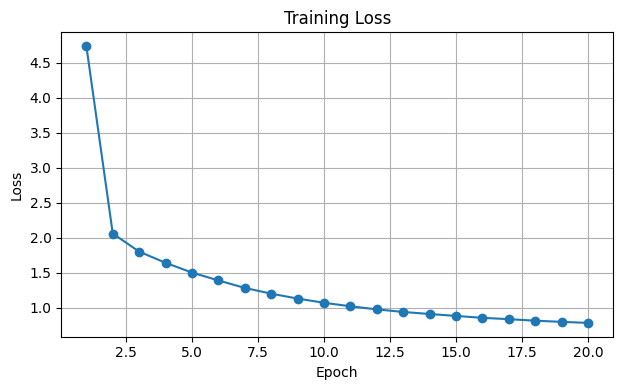


Evaluation on Full Test Set
ROC AUC: 0.7976705772708796
F1 Score: 0.0969947836370932
Confusion Matrix:
 [[  37271     336]
 [1496201   80374]]

Evaluation on Balanced Test Set
ROC AUC: 0.7976349669457945
F1 Score: 0.1526300522142719
Confusion Matrix:
 [[37003   604]
 [34450  3157]]


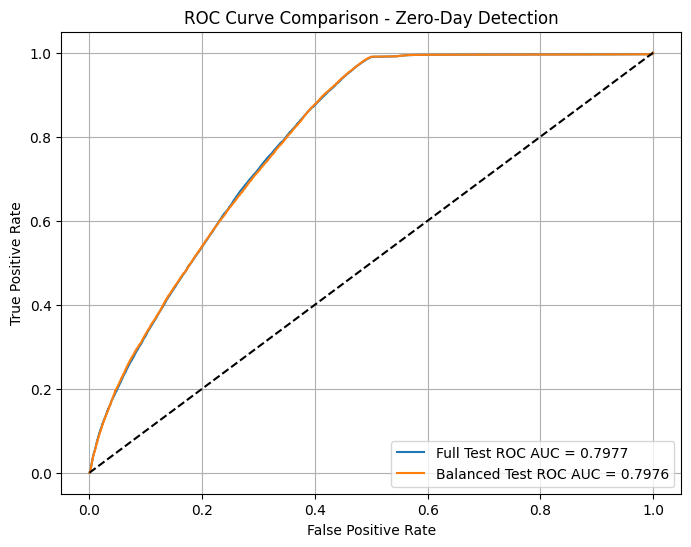

In [ ]:
# ======================= MAIN VAE PIPELINE =======================
input_dim = X_profiling.shape[1]
vae = VAE(input_dim=input_dim).to(device)
train_loader = DataLoader(torch.tensor(X_profiling, dtype=torch.float32), batch_size=128, shuffle=True)
train_vae(vae, train_loader, epochs=20, lr=1e-4)

# === (1) EVALUATION ON FULL TEST SET ===
scores_full = compute_anomaly_scores(vae, X_test)
thresh_full = np.percentile(scores_full, 95)
preds_full = (scores_full > thresh_full).astype(int)

print("\nEvaluation on Full Test Set")
print("ROC AUC:", roc_auc_score(Y_test, scores_full))
print("F1 Score:", f1_score(Y_test, preds_full))
print("Confusion Matrix:\n", confusion_matrix(Y_test, preds_full))


fpr_full, tpr_full, _ = roc_curve(Y_test, scores_full)
roc_auc_full = auc(fpr_full, tpr_full)

# === (2) EVALUATION ON BALANCED TEST SET ===
benign_test = test_data[test_data['Label'] == 0]
attack_test = test_data[test_data['Label'] == 1].sample(n=len(benign_test), random_state=42)
balanced_test = pd.concat([benign_test, attack_test], ignore_index=True).sample(frac=1.0, random_state=42)

X_test_balanced = scaler.transform(align_columns(balanced_test.drop(columns=['Label']), profiling_columns))
X_test_balanced = var_filter.transform(X_test_balanced)
X_test_balanced = np.clip(X_test_balanced, -5, 5)
Y_test_balanced = balanced_test['Label'].values

scores_bal = compute_anomaly_scores(vae, X_test_balanced)
thresh_bal = np.percentile(scores_bal, 95)
preds_bal = (scores_bal > thresh_bal).astype(int)

print("\nEvaluation on Balanced Test Set")
print("ROC AUC:", roc_auc_score(Y_test_balanced, scores_bal))
print("F1 Score:", f1_score(Y_test_balanced, preds_bal))
print("Confusion Matrix:\n", confusion_matrix(Y_test_balanced, preds_bal))

fpr_bal, tpr_bal, _ = roc_curve(Y_test_balanced, scores_bal)
roc_auc_bal = auc(fpr_bal, tpr_bal)

# === ROC CURVE COMPARISON ===
plt.figure(figsize=(8,6))
plt.plot(fpr_full, tpr_full, label=f"Full Test ROC AUC = {roc_auc_full:.4f}")
plt.plot(fpr_bal, tpr_bal, label=f"Balanced Test ROC AUC = {roc_auc_bal:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Zero-Day Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:

# ✅ Print to verify
print(f"[DEBUG] Balanced benign samples: {len(benign_test)}")
print(f"[DEBUG] Sampled attack samples: {len(attack_test)}")
print(f"[DEBUG] Total balanced test size: {len(balanced_test)}")
print(f"[DEBUG] Class distribution in balanced test:\n{balanced_test['Label'].value_counts()}")

[DEBUG] Balanced benign samples: 37607
[DEBUG] Sampled attack samples: 37607
[DEBUG] Total balanced test size: 75214
[DEBUG] Class distribution in balanced test:
Label
0    37607
1    37607
Name: count, dtype: int64
